# Deterministic Solution

Provides deterministic solution of the network capacity optimization problem given the following data and information about the uncertainty of the system:

| $C_x$ | $C_y$ | nominal demand $u^{\text{nom}}$ | $x$ bounds | $y$ bounds |
|---|---|---|---|---|
| $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[0, 100]$ |


In [1]:
from scipy.optimize import linprog, OptimizeResult
import matplotlib.pyplot as plt
import numpy as np

from common.plot_utils import apply_plot_style, setup_axes, finalize_figure
from common.config import OUTPUT_PATH

np.random.seed(3)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

apply_plot_style()

In [2]:
def display_result(result: OptimizeResult, A_ineq: np.ndarray, b: np.ndarray, u_nom: np.ndarray, figname: str) -> None:
    if result.success:
        a = result.x
        x_opt = a[:3]
        y_opt = a[3:]
        cost_opt = result.fun

        # Calculate uniform scale
        max_val = np.max(np.concatenate([u_nom, x_opt, y_opt]))
        y_max = max_val * 1.15 # 15% padding for labels

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Nominal demand profile at nodes
        nodes_demand = ['$\\xi$1', '$\\xi$2', '$\\xi$3', '$\\xi$4']
        axes[0].bar(nodes_demand, u_nom, color='#d62728')
        setup_axes(axes[0], title='Nominal demand profile at the nodes', ylabel='Demand')
        axes[0].set_ylim(0, y_max)
        for i, val in enumerate(u_nom):
            axes[0].text(i, val + max_val * 0.02, f'{int(val)}', ha='center', va='bottom', fontweight='bold')

        # Optimal generator capacities
        nodes_gen = ['x2', 'x3', 'x4']
        axes[1].bar(nodes_gen, x_opt, color='black')
        setup_axes(axes[1], title='Optimal Generator Capacities', ylabel='Capacity')
        axes[1].set_ylim(0, y_max)
        for i, val in enumerate(x_opt):
            axes[1].text(i, val + max_val * 0.02, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

        # Optimal transmission capacities
        lines = ['y1', 'y2', 'y3']
        axes[2].bar(lines, y_opt, color='#1f77b4')
        setup_axes(axes[2], title='Optimal Transmission Capacities', ylabel='Capacity')
        axes[2].set_ylim(0, y_max)
        for i, val in enumerate(y_opt):
            axes[2].text(i, val + max_val * 0.02, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

        finalize_figure(fig, OUTPUT_PATH / figname)

        # Print summary to console
        print(f"Optimal Design a* = [x*, y*]:")
        print(f"  Generation capacities x* = {x_opt.round(2)}")
        print(f"  Line capacities y* = {y_opt.round(2)}")
        print(f"\nMinimum investment cost: {cost_opt:.2f}")

        # Verify constraints
        constraint_values = A_ineq @ a - b
        print(f"\nConstraint violations:")
        constraints_desc = [
            "Total generation >= total demand",
            "Inflow at node 1 >= demand at node 1",
            "Node 2: x2 + y1 >= u2",
            "Node 3: x3 + y2 >= u3",
            "Node 4: x4 + y3 >= u4",
            "Line 1 excess capacity",
            "Line 2 excess capacity",
            "Line 3 excess capacity"
        ]

        for i, desc in enumerate(constraints_desc):
            status = "+" if constraint_values[i] >= 0 else "-"
            print(f"  {status} {desc}: {constraint_values[i]:.2f}")
    else:
        print("Optimization failed:", result.message)

In [3]:
C_x = np.array([5, 3, 4]) # generation costs at nodes 2, 3, 4
C_y = np.array([5, 4, 5]) # distribution line costs
c = np.concatenate([C_x, C_y]) # objective function coefficients

# Nominal demand
u_nom = np.array([22, 10, 25, 10])

# Constraint matrix -A_in (8 constraints)
A_ineq = np.array([
    [1, 1, 1, 0, 0, 0],   # total generation >= total demand
    [0, 0, 0, 1, 1, 1],   # inflow at node 1 >= demand at node 1
    [1, 0, 0, 1, 0, 0],   # node 2: generation + inflow >= demand
    [0, 1, 0, 0, 1, 0],   # node 3: generation + inflow >= demand
    [0, 0, 1, 0, 0, 1],   # node 4: generation + inflow >= demand
    [-1, 0, 0, 1, 0, 0],  # line 1 capacity for excess at node 2
    [0, -1, 0, 0, 1, 0],  # line 2 capacity for excess at node 3
    [0, 0, -1, 0, 0, 1]   # line 3 capacity for excess at node 4
])

B = np.array([
    [1, 1, 1, 1],   # total demand
    [1, 0, 0, 0],   # demand at node 1
    [0, 1, 0, 0],   # demand at node 2
    [0, 0, 1, 0],   # demand at node 3
    [0, 0, 0, 1],   # demand at node 4
    [0, -1, 0, 0],  # negative demand at node 2
    [0, 0, -1, 0],  # negative demand at node 3
    [0, 0, 0, -1]   # negative demand at node 4
])

# Right-hand side for constraints
b = B @ u_nom

# Bounds for variables
bounds = [(5, 100), (5, 100), (5, 100), (0, 100), (0, 100), (0, 100)]

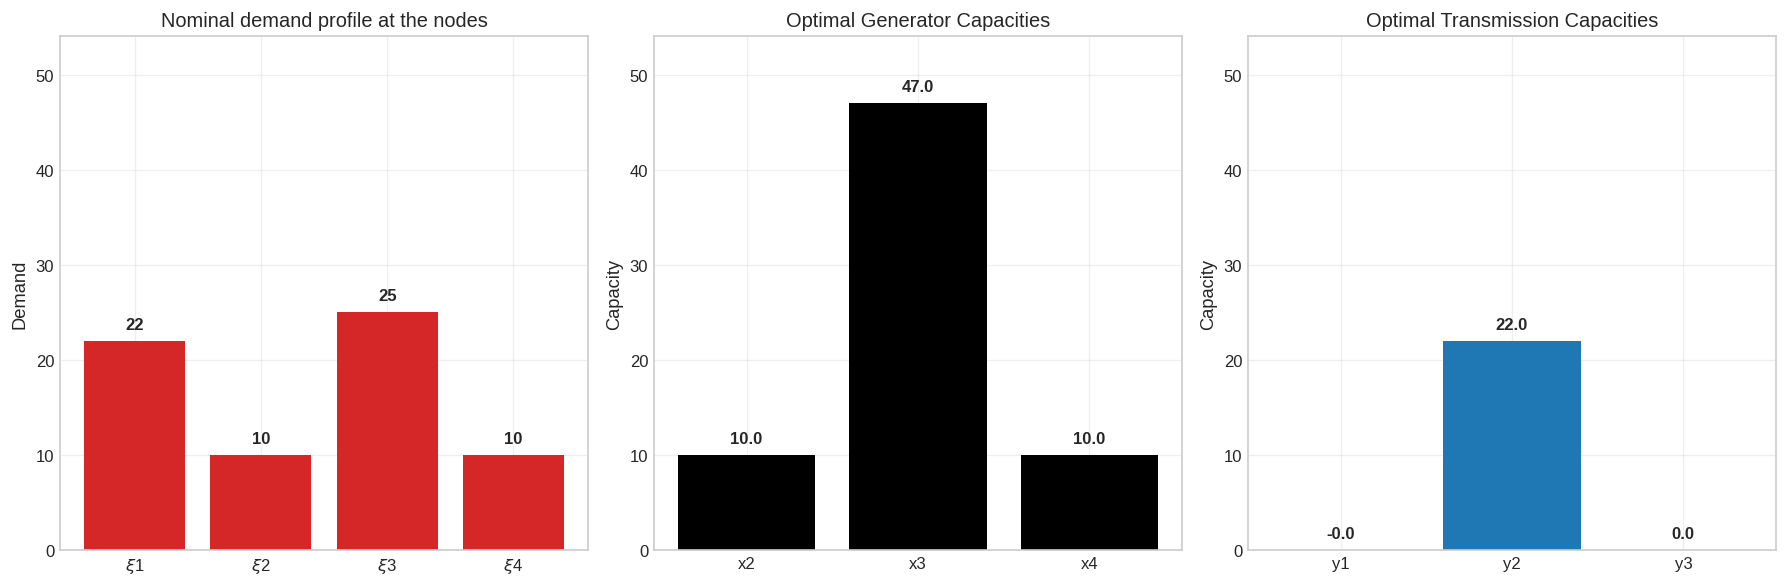

Optimal Design a* = [x*, y*]:
  Generation capacities x* = [10. 47. 10.]
  Line capacities y* = [-0. 22.  0.]

Minimum investment cost: 319.00

Constraint violations:
  + Total generation >= total demand: 0.00
  + Inflow at node 1 >= demand at node 1: 0.00
  + Node 2: x2 + y1 >= u2: 0.00
  + Node 3: x3 + y2 >= u3: 44.00
  + Node 4: x4 + y3 >= u4: 0.00
  + Line 1 excess capacity: 0.00
  + Line 2 excess capacity: 0.00
  + Line 3 excess capacity: 0.00


In [4]:
result = linprog(c, A_ub=-A_ineq, b_ub=-b, bounds=bounds, method='highs')

display_result(result, A_ineq, b, u_nom, "task1_deterministic_solution.png")

From the optimization result, nodes 2 and 4 nomare self-sufficient: their generation capacities match their own demands ($10$ CHF/pu given from the $u_{nom}$), hence, no line capacity is needed at those nodes. Node 3 was selected as the only node with surplus generation and, as a result, to install capacity there using line `y2` to export the excess 22 units to node 1, which has no local generation.

The total investment cost is 319 CHF. This is the cheapest feasible design because line `y2` and node 3 have the lowest unit cost among available options.

Since model did not consider any uncertainty, all constraints are respected with a slack for the constraint relative to node 3 of $44$, meaning that it is not binding.